In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [5]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [6]:
snapnum=25

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
pos = halos["GroupPos"]/1e3

In [9]:
sfr = halos["GroupSFR"]

In [10]:
mask = sfr > -1


In [11]:
pos1 = pos[mask]

In [12]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


(array([1.248380e+05, 3.323391e+06, 8.269296e+06, 4.002890e+06,
        1.035290e+06, 2.702450e+05, 6.479700e+04, 1.181500e+04,
        1.219000e+03, 6.800000e+01]),
 array([ 7.722711,  8.300881,  8.879051,  9.457222, 10.035392, 10.613563,
        11.191732, 11.769903, 12.348073, 12.926244, 13.504414],
       dtype=float32),
 <BarContainer object of 10 artists>)

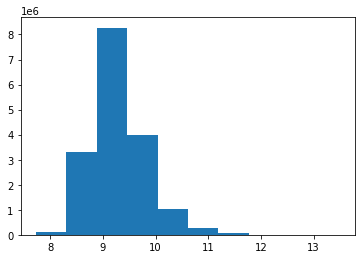

In [13]:
plt.hist(mvir[mvir>0])

In [14]:
rvir = halos["Group_R_TopHat200"]

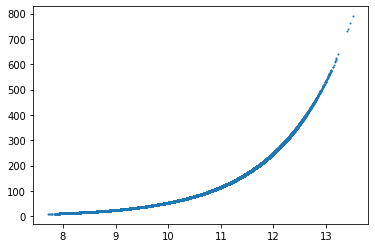

In [15]:
plt.scatter(mvir,rvir,s=1)

In [16]:
from Corrfunc.theory import xi

rmin = 0.01
rmax = 15.0
nbins = 100
boxsize = 205
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results = xi(boxsize, 2, bins , pos1[:,0],pos1[:,1],pos1[:,2], 
             weights=None,output_ravg=True)

Text(0, 0.5, '($\\xi$(r))')

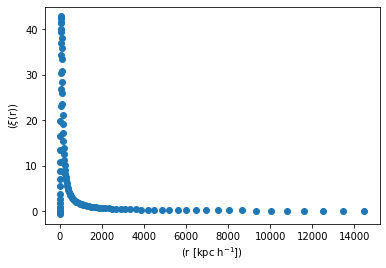

In [17]:
plt.scatter(results["ravg"]*1e3, results["xi"])
plt.xlabel("(r [kpc h$^{-1}$])")
plt.ylabel(r"($\xi$(r))")
#plt.ylim(-1,50)
#plt.xlim(0,1000)
